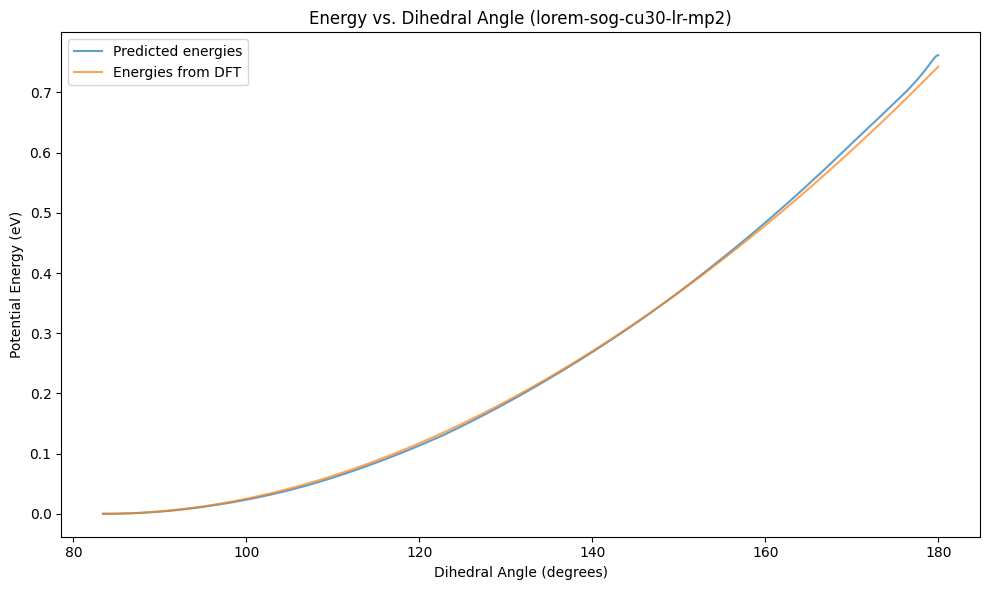

Saved plot to: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-sog-cu30-lr-mp2/cumulene_dihedral_energy_curve_replot.png
Saved data to: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-sog-cu30-lr-mp2/cumulene_dihedral_energy_curve_replot.npz


In [1]:
# 与 results_cumulene.py 一致风格：强制用 checkpoint + cumulene_profile.xyz 重算
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

workdir = Path('/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-sog-cu30-lr-mp2')
lorem_root = Path('/data/home/public/qiuqizhi/LOREM')
dataset_folder = lorem_root / 'datasets'
checkpoint_dir = workdir / 'run' / 'checkpoints' / 'R2_E+F'
out_path = workdir / 'cumulene_dihedral_energy_curve_replot.png'

# 使用 LOREM 原生 calculator
sys.path.insert(0, str(lorem_root / 'lorem'))
from calculator import Calculator


def assign_calculators(systems, calculator):
    for system in systems:
        system.calc = calculator


def order_by_dihedrals(systems, atom_indices=(0, 1, 11, 12)):
    dihedrals_local = np.array([sys.get_dihedral(*atom_indices) for sys in systems])
    order = np.argsort(dihedrals_local)
    systems[:] = [systems[i] for i in order]
    return dihedrals_local[order]


def get_energies(systems):
    energies = [sys.get_potential_energy() for sys in systems]
    min_e = min(energies)
    return np.array([e - min_e for e in energies])


xyz_path = dataset_folder / 'cumulene_profile.xyz'
assert xyz_path.exists(), f'数据文件不存在: {xyz_path}'
assert checkpoint_dir.exists(), f'checkpoint 不存在: {checkpoint_dir}'

systems = read(xyz_path, index=':')
dihedrals = order_by_dihedrals(systems)
actual_energies = get_energies(systems)

calc = Calculator.from_checkpoint(checkpoint_dir, add_offset=False)
assign_calculators(systems, calc)
predicted_energies = get_energies(systems)

# 按 results_cumulene.py 的绘图风格
plt.figure(figsize=(10, 6))
plt.plot(dihedrals, predicted_energies, label='Predicted energies', alpha=0.7)
plt.plot(dihedrals, actual_energies, label='Energies from DFT', alpha=0.7)
plt.xlabel('Dihedral Angle (degrees)')
plt.ylabel('Potential Energy (eV)')
plt.legend()
plt.title(f'Energy vs. Dihedral Angle ({workdir.stem})')
plt.tight_layout()
plt.savefig(out_path, dpi=200)
plt.show()

print('Saved plot to:', out_path)

# 保存本次重算数据
replot_npz = workdir / 'cumulene_dihedral_energy_curve_replot.npz'
np.savez(
    replot_npz,
    dihedrals=dihedrals,
    predicted_energies=predicted_energies,
    actual_energies=actual_energies,
)
print('Saved data to:', replot_npz)